
### Objetivos del Taller:
1. **Aplicar** técnicas de clustering en bases de datos reales y analizar los resultados.
2. **Experimentar** con reducción de dimensionalidad para visualizar y preprocesar datos.
3. **Evaluar** métodos de detección de anomalías en diferentes contextos de datos.

---
### Sección 1: Clustering

#### Ejercicio 1: K-means y DBSCAN en datos de clientes
- **Dataset:** Utilizar la base de datos Online Retail.xlsx .
- **Objetivo:** Segmentar a los clientes en grupos basados en sus patrones de compra.
- **Pasos:**
  - Aplicar **k-means** y ajustar el número de clusters con el método del codo.
  - Ejecutar **DBSCAN** con diferentes valores de epsilon y min_samples, analizando cómo cambia la cantidad de clusters y la detección de outliers.
  - Comparar los resultados de ambas técnicas y discutir en qué contextos uno es preferible sobre el otro.

#### Ejercicio 2: Clustering Jerárquico y GMM en datos de salud
- **Dataset:** Datos de salud pública con varias características de enfermedades (por ejemplo, diabetes o enfermedades cardiovasculares).
- **Objetivo:** Identificar subgrupos de pacientes con características similares.
- **Pasos:**
  - Aplicar **clustering jerárquico** y generar un dendrograma. Decidir el número óptimo de clusters.
  - Implementar **Gaussian Mixture Models (GMM)** y ajustar el número de componentes.
  - Evaluar las características de cada grupo, observando diferencias entre métodos y cómo manejan la varianza de los datos.

usa el siguiente código para general la base de datos.

```
!pip install ucimlrepo


from ucimlrepo import fetch_ucirepo
  
# fetch dataset
heart_disease = fetch_ucirepo(id=45)
  
# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets
  
# metadata
print(heart_disease.metadata)
  
# variable information
print(heart_disease.variables)

```
---

### Sección 2: Reducción de Dimensionalidad

#### Ejercicio 3: PCA y Kernel PCA para visualización de datos de alta dimensionalidad
- **Dataset:** Utilizar un conjunto de datos de imágenes  Fashion MNIST, busque en la documentación de Keras para hacerlo.
- **Objetivo:** Reducir la dimensionalidad para visualizar patrones en los datos.
- **Pasos:**
  - Aplicar **PCA** para reducir las dimensiones a 2 y 3 dimensiones y visualizar.
  - Ejecutar **kernel PCA** (por ejemplo, con un kernel polinómico o RBF) y comparar los resultados con PCA lineal.
  - Discutir cuándo PCA lineal es insuficiente y cómo el uso de kernels ayuda a mejorar la representación de los datos.

#### Ejercicio 4: t-SNE y UMAP en datos de productos de un ecommerce
- **Dataset:** Información de las transacciones de los clientes en el dataset general.csv.
- **Objetivo:** Explorar si existen agrupaciones naturales entre los clientes.
- **Pasos:**
  - Usar **t-SNE** y **UMAP** para visualizar en 2D y 3D los clientes y sus similitudes.
  - Comparar la velocidad de ambos métodos y su capacidad para capturar relaciones locales.
  - Comentar las limitaciones de t-SNE en grandes volúmenes de datos y la ventaja de UMAP en visualización y rendimiento.



---

### Sección 3: Detección de Anomalías

#### Ejercicio 5: Envoltura Elíptica e Isolation Forest en consumo energético

El ejercicio implicará:
1. Cargar el dataset y transformar las mediciones en series temporales.
2. Calcular diferencias de consumo a intervalos específicos para detectar cambios bruscos.
3. Aplicar **Isolation Forest** para identificar intervalos anómalos en el consumo.
4. Aplica **Envoltura Elíptica** para identiticar intervalos anólaos en el consumo
5. Compara los resultados de los dos algorítmos.

Usa el archivo LD2011_2014.

#### Ejercicio 6: One-Class SVM y Local Outlier Factor (LOF) en datos de sensores de maquinaria
- **Dataset:** Datos de sensores de maquinaria en operación que se encuentran en la base de datos train_FD001.txt.
- **Objetivo:** Detectar fallas en la maquinaria mediante el análisis de anomalías.
- **Pasos:**
  - Implementar **One-Class SVM** y ajustar el parámetro de nu (anomalías esperadas).
  - Usar **Local Outlier Factor (LOF)** para detectar puntos locales que se alejan de sus vecinos.
  - Evaluar cuál método es más efectivo y qué tipos de anomalías detecta mejor en este contexto.

Del datset compartido debe eliminar las columnas 26 y 27 y luego usar el siguiente nombre de las columnas:

```
column_names = ["unit_number","time_in_cycles","setting1","setting2","setting3",
                "s01","s02",
                "s03","s04",
                "s05","s06",
                "s07","s08",
                "s09","s10",
                "s11","s12",
                "s13","s14",
                "s15","s16",
                "s17","s18",
                "s19","s20",
                "s21"]

 ```


### Sección 1: Clustering

#### Ejercicio 1: K-means y DBSCAN en datos de clientes
- **Dataset:** Utilizar la base de datos Online Retail.xlsx .
- **Objetivo:** Segmentar a los clientes en grupos basados en sus patrones de compra.
- **Pasos:**
  - Aplicar **k-means** y ajustar el número de clusters con el método del codo.
  - Ejecutar **DBSCAN** con diferentes valores de epsilon y min_samples, analizando cómo cambia la cantidad de clusters y la detección de outliers.
  - Comparar los resultados de ambas técnicas y discutir en qué contextos uno es preferible sobre el otro.


In [1]:
# Montar google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/My Drive/Curso Mineria de Datos 2024/Semana 11  - Aprendizaje no Supervisado - Reducción de la Dimensionalidad/Online Retail.xlsx'

In [4]:
# librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
# cargar base de datos
df = pd.read_excel(file_path)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [9]:
df['TotalPrice']= df['Quantity'] * df['UnitPrice']



La base de datos con información de los clientes

In [10]:
Custumer_Data = df.groupby(['CustomerID']).agg({'InvoiceNo':'count',
                                        'TotalPrice':'sum',
                                        'Quantity':'sum'}).rename(columns={'InvoiceNo':'TransactionsCount'})
#

In [11]:
Custumer_Data.head()

,TransactionsCount,TotalPrice,Quantity
CustomerID,,,
12346.0,2,0.00,0
12347.0,182,4310.00,2458
12348.0,31,1797.24,2341
12349.0,73,1757.55,631
12350.0,17,334.40,197


Podríamos hacer todo el análisis exploratorio que queramos usando estas 3 variables.

In [12]:
# Escalar los datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(Custumer_Data)


In [13]:
inercia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inercia.append(kmeans.inertia_)

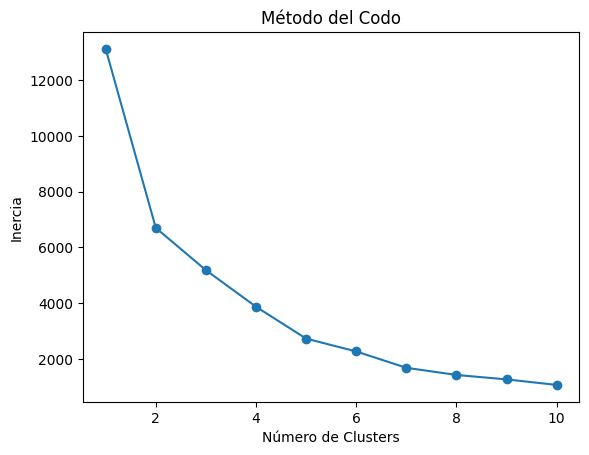

In [14]:
# plotear los resultados de la inercia
plt.plot(range(1, 11), inercia, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

Del análisis del gráfico del codo podemos ver que un valor de 5 para el número de clusters resulta atrativo usando la métrica de la inercia.

In [ ]:
# Evaluación usando siluete score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)



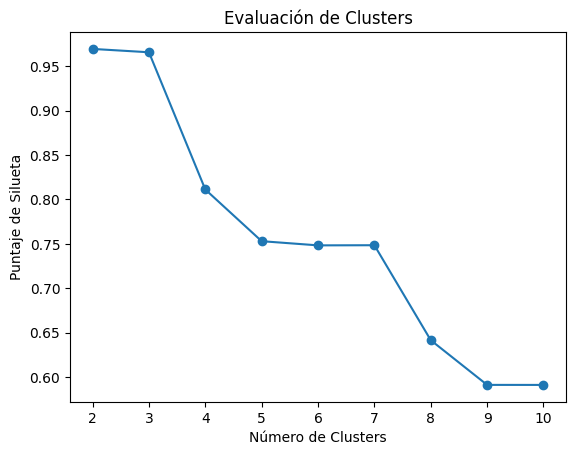

In [ ]:
# gráfica del puntaje de silueta
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntaje de Silueta')
plt.title('Evaluación de Clusters')
plt.show()

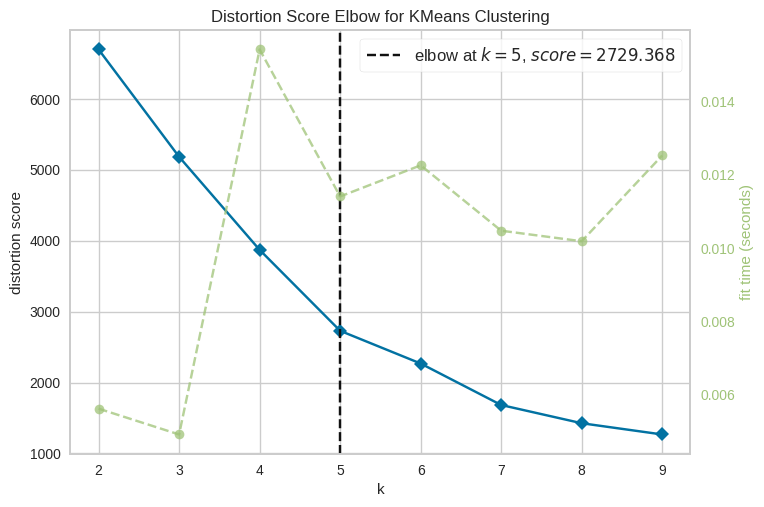

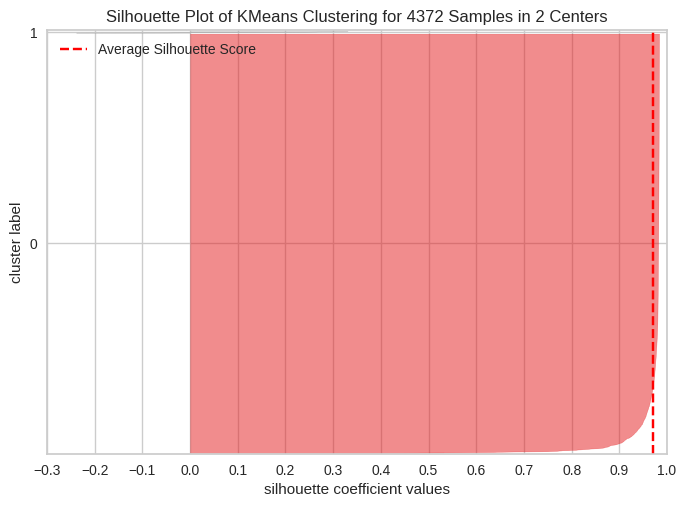

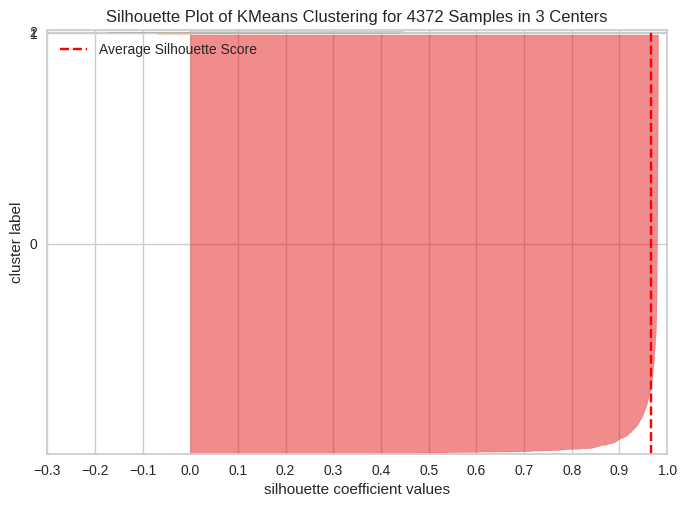

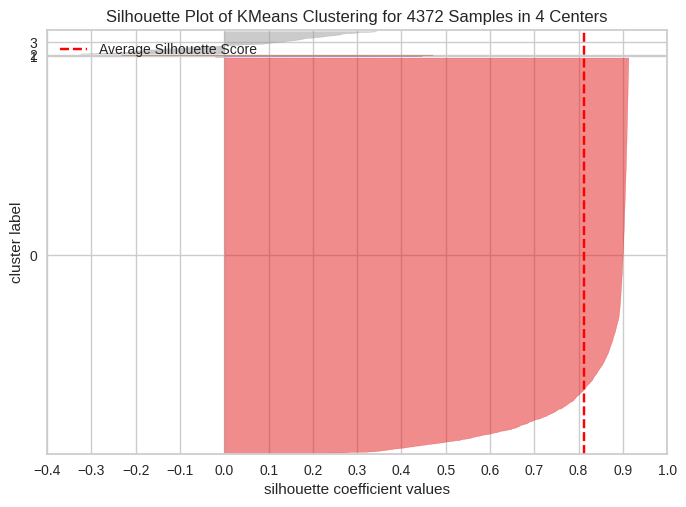

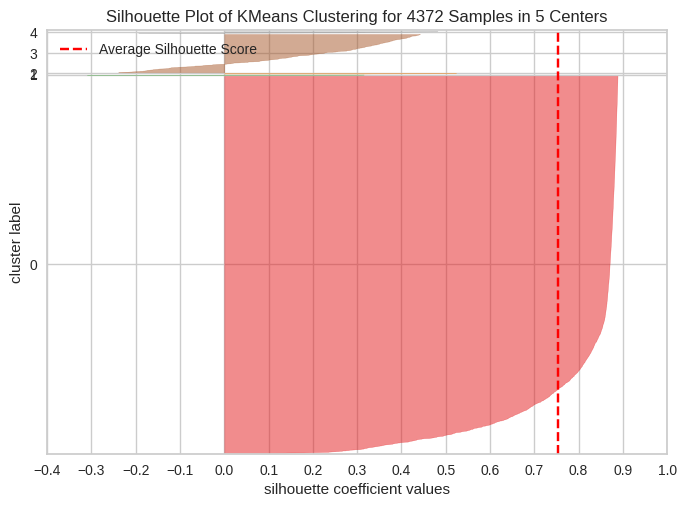

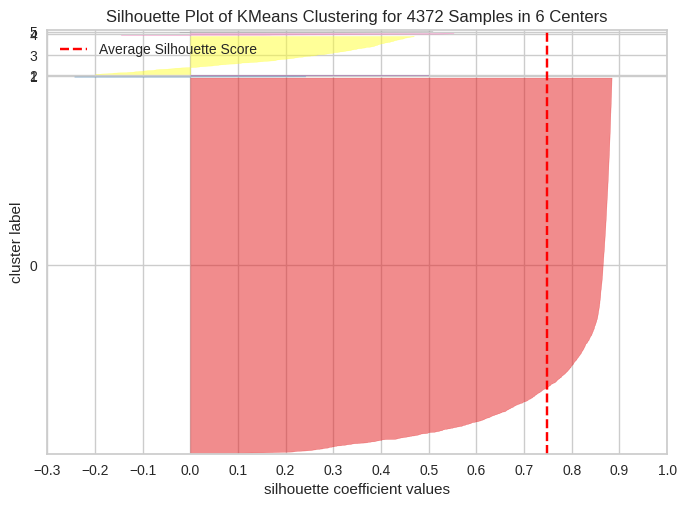

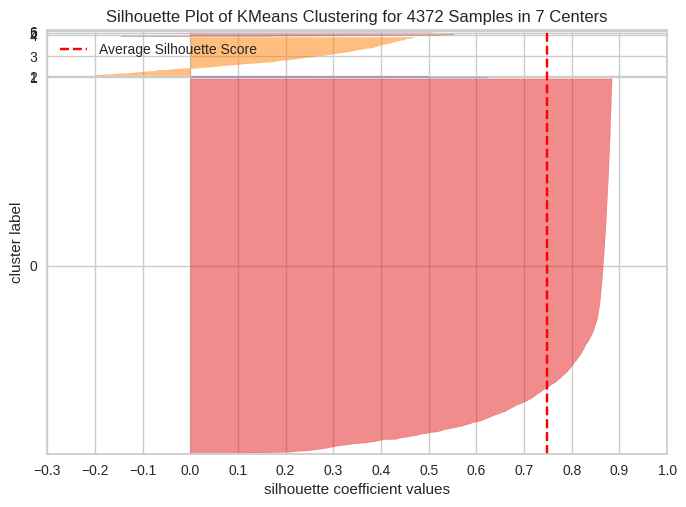

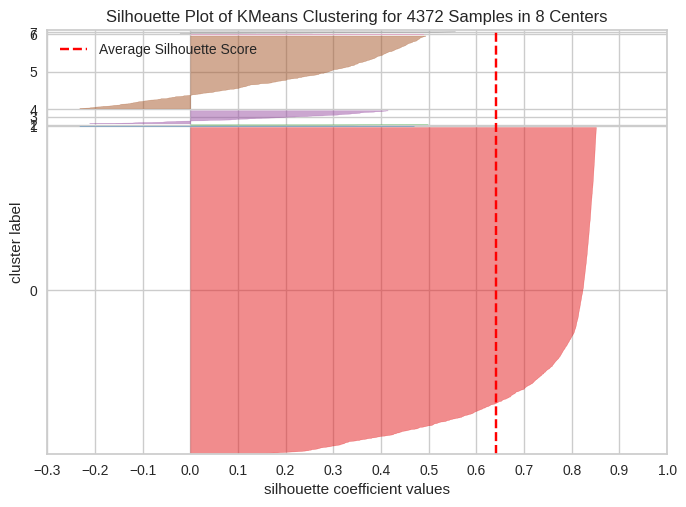

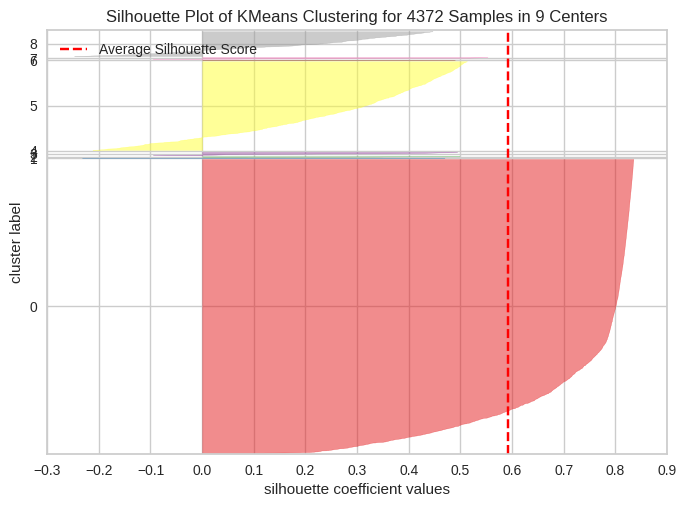

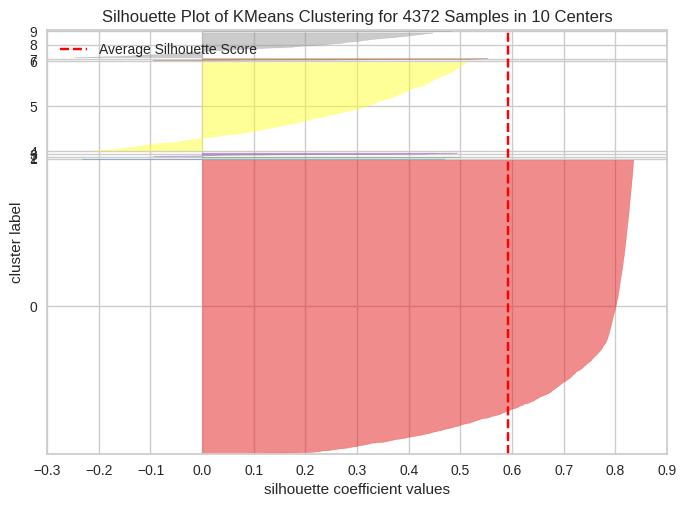

In [ ]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

#  https://www.scikit-yb.org/en/latest/
# visualizar el método del codo
Visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,10))
Visualizer.fit(scaled_data)
Visualizer.show()

# visualizar el silhoute Score
for i in range(2, 11):
  Visualizer = SilhouetteVisualizer(KMeans(i,random_state=42))
  Visualizer.fit(scaled_data)
  Visualizer.show()




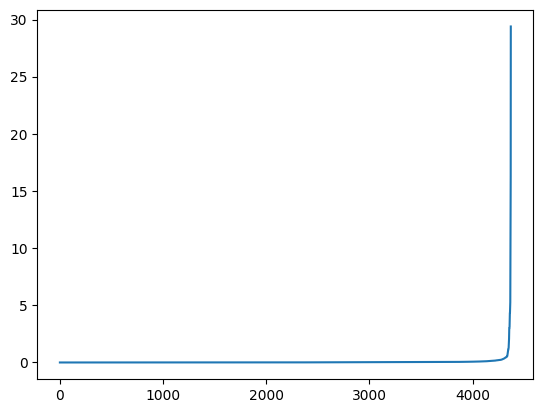

In [15]:
# Aplicar DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples = 5 # valores típicos 5, 10, 15

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)

# Gráficar las distancias k-ésimas
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)
plt.show()


Basados en este analisis se podría ajustar el siguiente modelo de clustering:

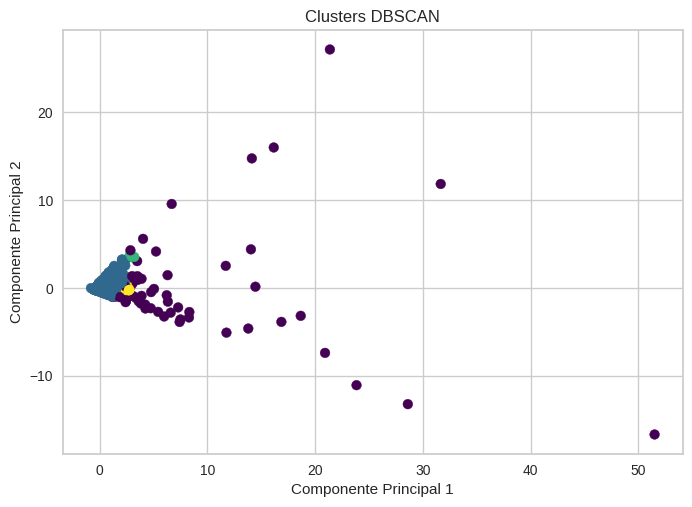

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
cluster_labels = dbscan.fit_predict(scaled_data)

# gráficar clusters usando pca (es la más rápida)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters DBSCAN')
plt.show()


In [17]:
# como hallarían estos dos hiperparamétros usando score de la silueta.

eps_range = np.linspace(0.1, 1.0, 10)
min_samples_range = np.arange(2, 11)

best_score = -1
best_eps = 0
best_min_samples = 0
results = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(scaled_data)
        if len(np.unique(labels)) > 1:  # Excluir clusters sin puntos
          score = silhouette_score(scaled_data, labels)
          results.append((eps, min_samples, score))
          if score > best_score:
            best_score = score
            best_eps = eps
            best_min_samples = min_samples

In [19]:
# mostrar los resultados
for eps, min_samples, score in results:
    print(f"eps: {best_eps}, min_samples: {best_min_samples}, Score de Silueta: {best_score}")

eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.9477167799694572
eps: 1.0, min_samples: 4, Score de Silueta: 0.947716779

In [ ]:
# Comparar los grupos creados por ambas técnicas, determinando similutes y discrepancias. Si piensan desde el punto de vista del negocio cual de los usarían y porqué


#### Ejercicio 2: Clustering Jerárquico y GMM en datos de salud
- **Dataset:** Datos de salud pública con varias características de enfermedades (por ejemplo, diabetes o enfermedades cardiovasculares).
- **Objetivo:** Identificar subgrupos de pacientes con características similares.
- **Pasos:**
  - Aplicar **clustering jerárquico** y generar un dendrograma. Decidir el número óptimo de clusters.
  - Implementar **Gaussian Mixture Models (GMM)** y ajustar el número de componentes.
  - Evaluar las características de cada grupo, observando diferencias entre métodos y cómo manejan la varianza de los datos.

usa el siguiente código para general la base de datos.

```
!pip install ucimlrepo


from ucimlrepo import fetch_ucirepo
  
# fetch dataset
heart_disease = fetch_ucirepo(id=45)
  
# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets
  
# metadata
print(heart_disease.metadata)
  
# variable information
print(heart_disease.variables)

```

In [20]:
!pip install ucimlrepo



In [21]:

from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features # (lo que nos sirve para el ejercicio de clustering)
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
heart_disease.metadata

{'uci_id': 45,
 'name': 'Heart Disease',
 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease',
 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv',
 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 303,
 'num_features': 13,
 'feature_types': ['Categorical', 'Integer', 'Real'],
 'demographics': ['Age', 'Sex'],
 'target_col': ['num'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1989,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C52P4X',
 'creators': ['Andras Janosi',
  'William Steinbrunn',
  'Matthias Pfisterer',
  'Robert Detrano'],
 'intro_paper': {'ID': 231,
  'type': 'NATIVE',
  'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.',
  'authors': 'R. Detr

In [22]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [ ]:
 # Nesecistmos hacer un pipeline que incluya imputación para la variable ca y luego estandarización de todas las variables excepto aquellas que son binarias

# Imputación de la variable 'ca' (asumiendo que 'ca' es numérica y se puede imputar con la mediana)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')  # Usar la mediana para la imputación
X['ca'] = imputer.fit_transform(X[['ca']])

# Identificar variables binarias
binary_variables = []
for col in X.columns:
    if X[col].nunique() == 2:
        binary_variables.append(col)

# Variables a escalar (todas excepto las binarias)
variables_to_scale = [col for col in X.columns if col not in binary_variables]

# Estandarización
scaler = StandardScaler()
X[variables_to_scale] = scaler.fit_transform(X[variables_to_scale])

X

<ipython-input-26-e83ed9467db7>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ca'] = imputer.fit_transform(X[['ca']])
<ipython-input-26-e83ed9467db7>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[variables_to_scale] = scaler.fit_transform(X[variables_to_scale])


In [ ]:
X['thal'] = imputer.fit_transform(X[['thal']])

<ipython-input-31-4c5b2fcdc2d3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['thal'] = imputer.fit_transform(X[['thal']])


In [ ]:
X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


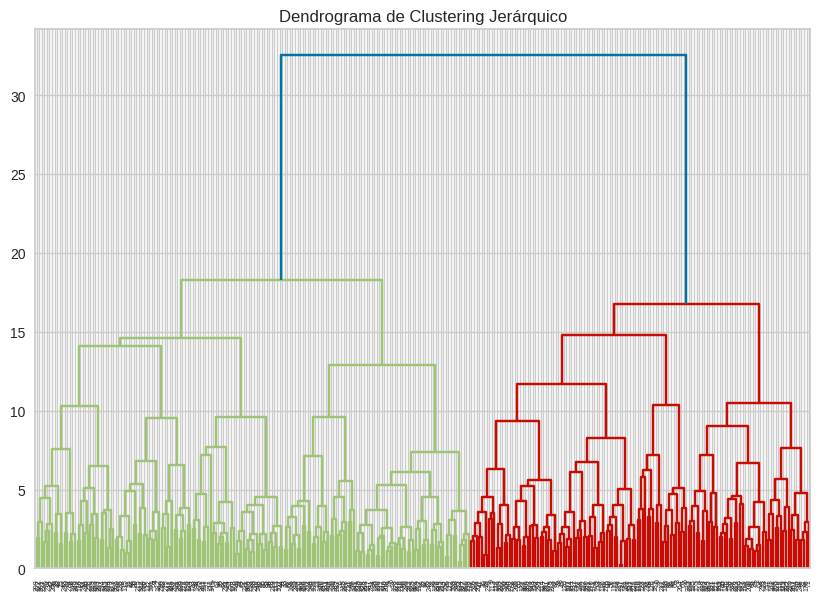

In [ ]:
# REalizar un cluster aglomerativo
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Crear el linkage para el dendrograma
linked = linkage(X, method='ward')

# Dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrograma de Clustering Jerárquico')
plt.show()

In [ ]:
# prompt: Cree clusters aglomerativos usando un linkage ward y un numero de clusters igual a 4

# Realizar clustering aglomerativo con Ward linkage y 4 clusters
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters = agg_clustering.fit_predict(X)

# Agregar los clusters al DataFrame original
X['cluster_aglomearativo'] = clusters

# Mostrar los primeros registros con la asignación de clusters
print(X.head())

        age  sex        cp  trestbps  ...     slope        ca      thal  cluster_aglomearativo
0  0.948726    1 -2.251775  0.757525  ...  2.274579 -0.711131  0.653650                      0
1  1.392002    1  0.877985  1.611220  ...  0.649113  2.504881 -0.895552                      3
2  1.392002    1  0.877985 -0.665300  ...  0.649113  1.432877  1.170051                      3
3 -1.932564    1 -0.165268 -0.096170  ...  2.274579 -0.711131 -0.895552                      0
4 -1.489288    0 -1.208521 -0.096170  ... -0.976352 -0.711131 -0.895552                      1

[5 rows x 14 columns]


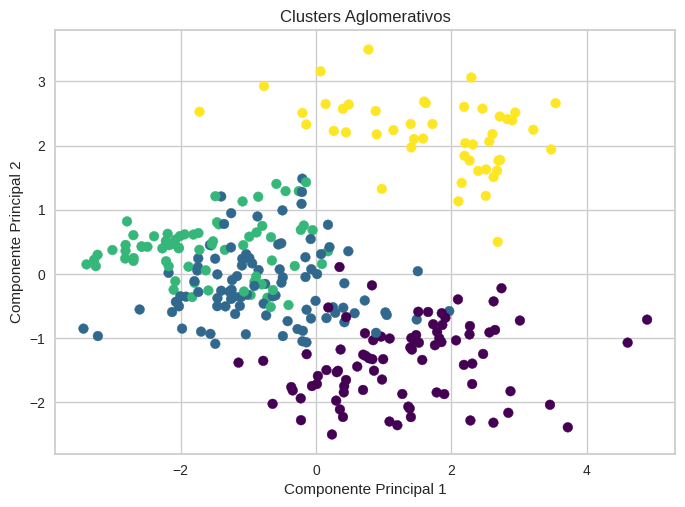

In [ ]:
# prompt: Visualizar los clusters usando pca

# Gráficar clusters usando PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters Aglomerativos')
plt.show()

        age  sex        cp  trestbps  ...        ca      thal  cluster_aglomearativo  cluster_gmm
0  0.948726    1 -2.251775  0.757525  ... -0.711131  0.653650                      0            0
1  1.392002    1  0.877985  1.611220  ...  2.504881 -0.895552                      3            2
2  1.392002    1  0.877985 -0.665300  ...  1.432877  1.170051                      3            2
3 -1.932564    1 -0.165268 -0.096170  ... -0.711131 -0.895552                      0            0
4 -1.489288    0 -1.208521 -0.096170  ... -0.711131 -0.895552                      1            3

[5 rows x 15 columns]


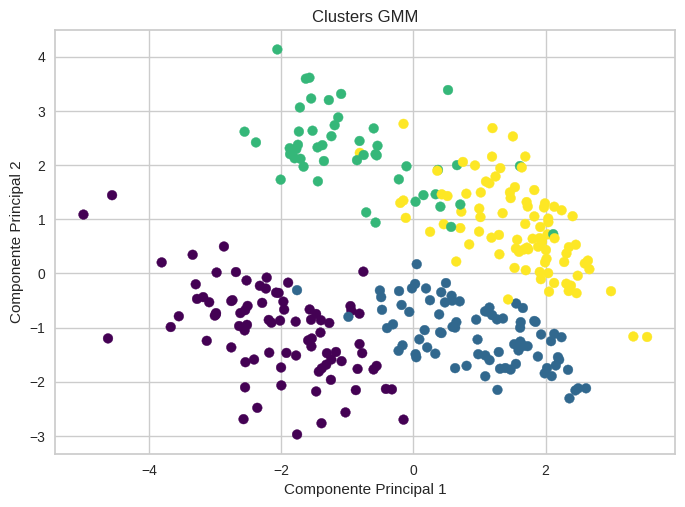

In [ ]:
# prompt: Usando un numero de cluster de 4 , realiza un agrupamiento usando Gaussian Mistured Mixde

from sklearn.mixture import GaussianMixture


# Apply Gaussian Mixture Model with 4 components
gmm = GaussianMixture(n_components=4, random_state=42)  # Use random_state for reproducibility
gmm_labels = gmm.fit_predict(X)

# Add GMM cluster labels to the DataFrame
X['cluster_gmm'] = gmm_labels

# Print the first few rows to inspect the cluster assignments
print(X.head())

# Visualize the GMM clusters using PCA (same PCA as in the previous example)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=gmm_labels, cmap='viridis')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters GMM')
plt.show()

In [ ]:
# En analisis de multiples dimensiones, la covarianza es una matriz, GMM nos brinda información en el objeto ajustado. Ahora queda averiguar como calcular la matriz para los grupos creados por el cluster aglomearativo.



---

### Sección 2: Reducción de Dimensionalidad

#### Ejercicio 3: PCA y Kernel PCA para visualización de datos de alta dimensionalidad
- **Dataset:** Utilizar un conjunto de datos de imágenes  Fashion MNIST, busque en la documentación de Keras para hacerlo.
- **Objetivo:** Reducir la dimensionalidad para visualizar patrones en los datos.
- **Pasos:**
  - Aplicar **PCA** para reducir las dimensiones a 2 y 3 dimensiones y visualizar.
  - Ejecutar **kernel PCA** (por ejemplo, con un kernel polinómico o RBF) y comparar los resultados con PCA lineal.
  - Discutir cuándo PCA lineal es insuficiente y cómo el uso de kernels ayuda a mejorar la representación de los datos.

#### Ejercicio 4: t-SNE y UMAP en datos de productos de un ecommerce
- **Dataset:** Información de las transacciones de los clientes en el dataset general.csv.
- **Objetivo:** Explorar si existen agrupaciones naturales entre los clientes.
- **Pasos:**
  - Usar **t-SNE** y **UMAP** para visualizar en 2D y 3D los clientes y sus similitudes.
  - Comparar la velocidad de ambos métodos y su capacidad para capturar relaciones locales.
  - Comentar las limitaciones de t-SNE en grandes volúmenes de datos y la ventaja de UMAP en visualización y rendimiento.


In [23]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.decomposition import PCA, KernelPCA


# Cargar el dataset de Fashion MNIST
(X_train, y_train), (_, _) = fashion_mnist.load_data()

X_sample = X_train[:2000]
y_sample = y_train[:2000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
# Definir las etiquetas de clase
class_labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


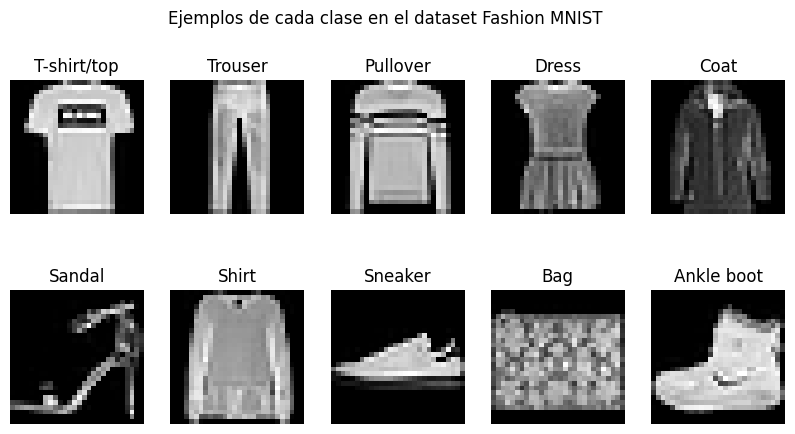

In [25]:
# Mostrar algunas muestras del dataset
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_sample[y_sample == i][0], cmap="gray")
    plt.title(class_labels[i])
    plt.axis("off")
plt.suptitle("Ejemplos de cada clase en el dataset Fashion MNIST")
plt.show()

In [26]:
# Aplanar las imágenes de 28x28 a vectores de 784 características
X_sample = X_sample.reshape(-1, 784).astype("float32")

In [27]:
X_sample

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [28]:
# normalizaci'on

X_sample /= 255.0


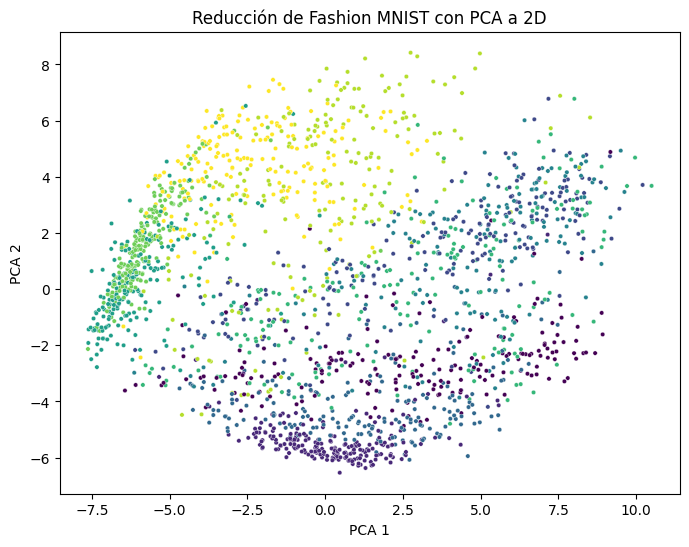

In [29]:
# PCA en 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Visualización de PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, palette="viridis", s=10, legend=False)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Reducción de Fashion MNIST con PCA a 2D')
plt.show()

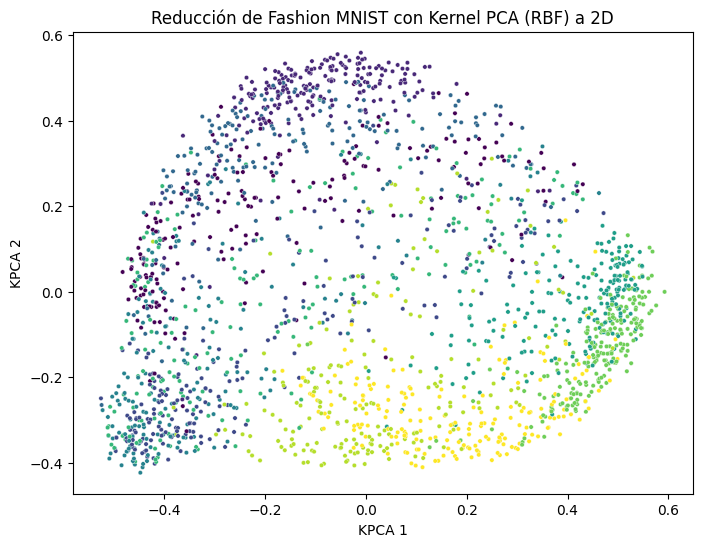

In [30]:
# Kernel PCA con kernel RBF
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.01)
X_kpca = kpca.fit_transform(X_sample)

# Visualización de Kernel PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_kpca[:, 0], y=X_kpca[:, 1], hue=y_sample, palette="viridis", s=10, legend=False)
plt.xlabel('KPCA 1')
plt.ylabel('KPCA 2')
plt.title('Reducción de Fashion MNIST con Kernel PCA (RBF) a 2D')
plt.show()

In [31]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.1 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


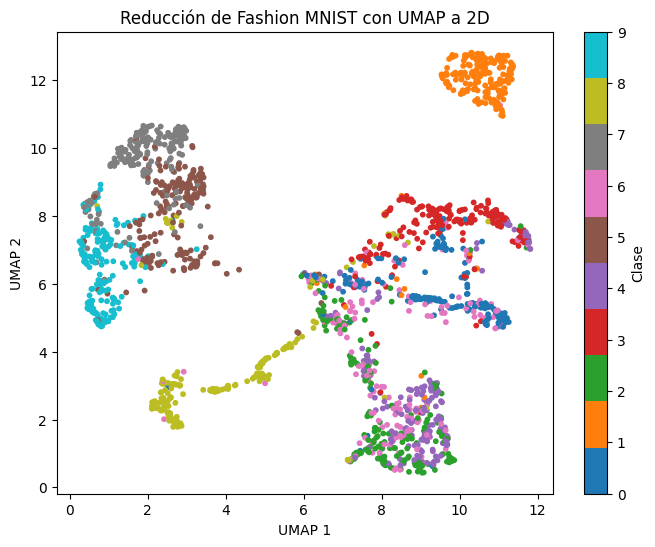

In [32]:
import umap

# UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_sample)

# Visualización de UMAP con barra lateral de colores
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap="tab10", s=10)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('Reducción de Fashion MNIST con UMAP a 2D')
plt.colorbar(scatter, ticks=range(10), label='Clase')
plt.show()


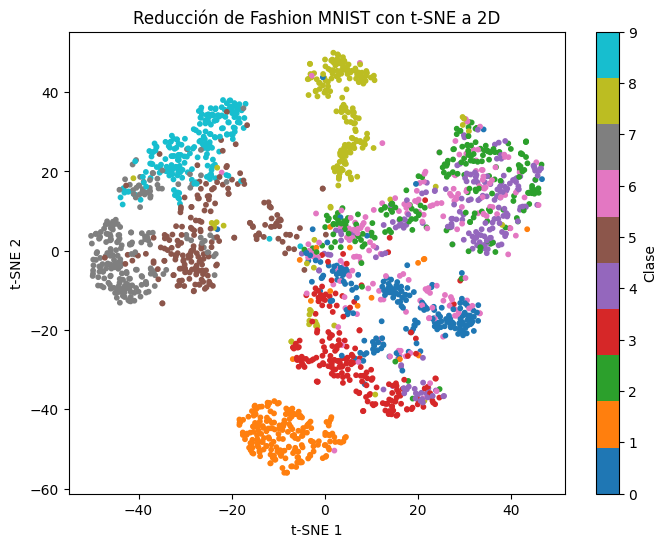

In [33]:
from sklearn.manifold import TSNE

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Visualización de t-SNE con barra lateral de colores
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap="tab10", s=10)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Reducción de Fashion MNIST con t-SNE a 2D')
plt.colorbar(scatter, ticks=range(10), label='Clase')
plt.show()

In [34]:
# cargar archivo de excel
# -----------------------------
# Reading the database
# -----------------------------
file_path = '/content/drive/My Drive/Curso Mineria de Datos 2024/Semana 11  - Aprendizaje no Supervisado - Reducción de la Dimensionalidad/general.csv'
data = pd.read_csv(file_path)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
data_imputed= imputer.fit_transform(data.drop(columns=['CUST_ID']))

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

In [38]:
import time

# t-SNE
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(data_scaled)
end_time = time.time()


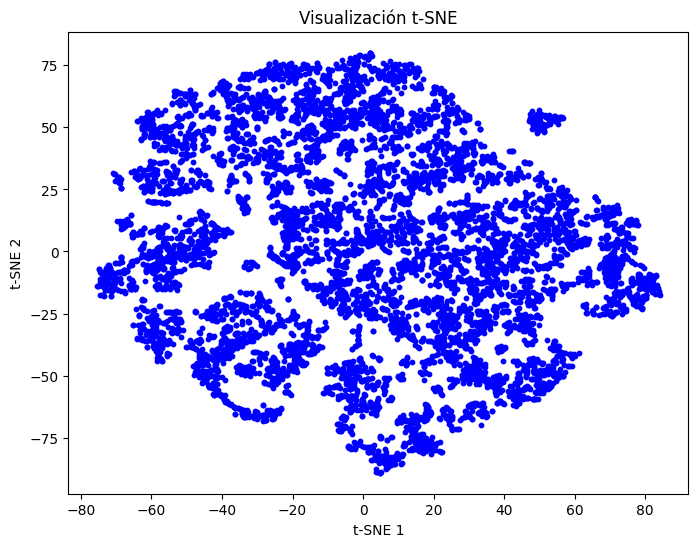

In [39]:
# Visualización de t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c='blue', s=10)
plt.title("Visualización t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [44]:
kmeans_tsne = KMeans(n_clusters=5, random_state=42)
cluster_labels_tsne = kmeans_tsne.fit_predict(X_tsne)

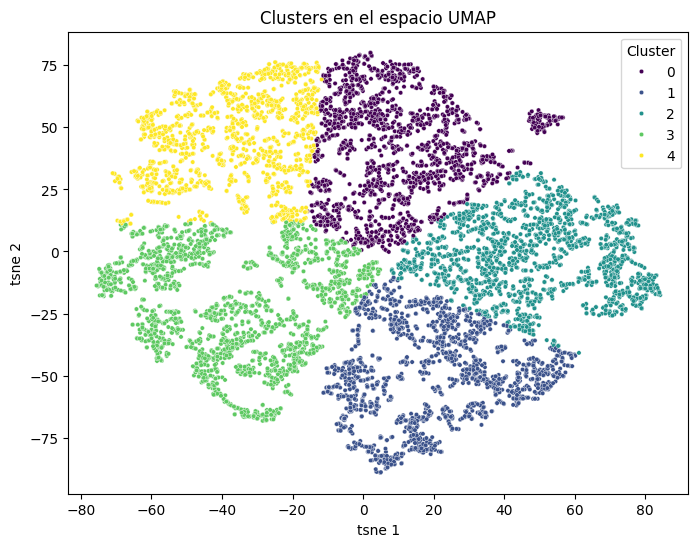

In [45]:
# Visualización de clusters en el espacio UMAP
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_labels_tsne, palette="viridis", s=10)
plt.title("Clusters en el espacio UMAP")
plt.xlabel("tsne 1")
plt.ylabel("tsne 2")
plt.legend(title="Cluster")
plt.show()

In [40]:
print(f"Tiempo de ejecución de t-SNE: {end_time - start_time} segundos")

Tiempo de ejecución de t-SNE: 186.94342684745789 segundos


In [41]:
# UMAP
start_time = time.time()
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(data_scaled)
end_time = time.time()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


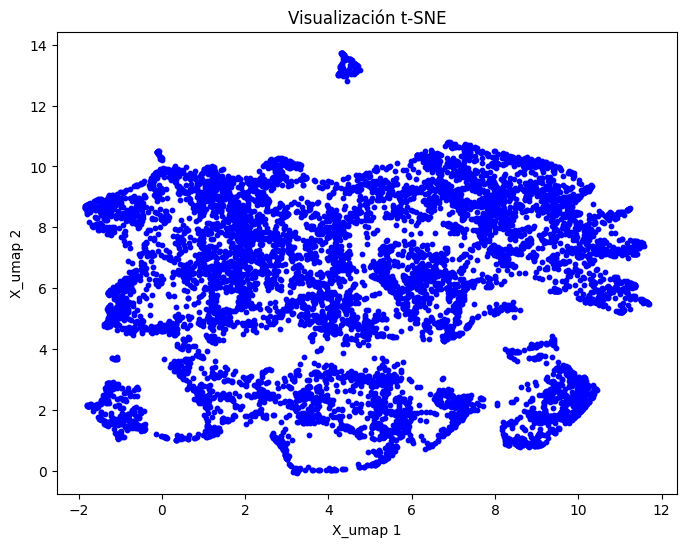

In [42]:
# Visualización de t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c='blue', s=10)
plt.title("Visualización t-SNE")
plt.xlabel("X_umap 1")
plt.ylabel("X_umap 2")
plt.show()

In [43]:
print(f"Tiempo de ejecución de UMAP: {end_time - start_time} segundos")

Tiempo de ejecución de UMAP: 47.86464881896973 segundos


---

### Sección 3: Detección de Anomalías

#### Ejercicio 5: Envoltura Elíptica e Isolation Forest en consumo energético

El ejercicio implicará:
1. Cargar el dataset y transformar las mediciones en series temporales.
2. Calcular diferencias de consumo a intervalos específicos para detectar cambios bruscos.
3. Aplicar **Isolation Forest** para identificar intervalos anómalos en el consumo.
4. Aplica **Envoltura Elíptica** para identiticar intervalos anólaos en el consumo
5. Compara los resultados de los dos algorítmos.

Usa el archivo LD2011_2014. (Bono para la prueba 3, entrega max dom 10 nov.)



#### Ejercicio 6: One-Class SVM y Local Outlier Factor (LOF) en datos de sensores de maquinaria
- **Dataset:** Datos de sensores de maquinaria en operación que se encuentran en la base de datos train_FD001.txt.
- **Objetivo:** Detectar fallas en la maquinaria mediante el análisis de anomalías.
- **Pasos:**
  - Implementar **One-Class SVM** y ajustar el parámetro de nu (anomalías esperadas).
  - Usar **Local Outlier Factor (LOF)** para detectar puntos locales que se alejan de sus vecinos.
  - Evaluar cuál método es más efectivo y qué tipos de anomalías detecta mejor en este contexto.

Del datset compartido debe eliminar las columnas 26 y 27 y luego usar el siguiente nombre de las columnas:

```
column_names = ["unit_number","time_in_cycles","setting1","setting2","setting3",
                "s01","s02",
                "s03","s04",
                "s05","s06",
                "s07","s08",
                "s09","s10",
                "s11","s12",
                "s13","s14",
                "s15","s16",
                "s17","s18",
                "s19","s20",
                "s21"]

 ```
